# Integration timestep convergence

## 1. Objective and numerical protocol

The aim of this analysis is to determine the largest integration timestep $\Delta t$ that reproduces the dynamics obtained in the small-timestep limit while keeping the simulations computationally feasible.

All simulations are compared at equal physical time. The timestep values considered are

$$
\Delta t = 0.001,\; 0.005,\; 0.01,\; 0.025,\; 0.05,\; 0.1,
$$

with the two smallest values incorporated once their simulations are completed.

The remaining numerical and model parameters are kept fixed. In particular, the simulations use $N=1000$, $\kappa=2.5$, $\lambda=1$, no translational or rotational noise, and a fixed deformation period in physical time. Four densities are considered in order to test convergence across different dynamical regimes.

The smallest available timestep is used as a numerical reference. It is not assumed to represent the exact solution; rather, convergence is assessed by determining whether observables become insensitive to further reductions of $\Delta t$.

The analysis proceeds from microscopic numerical diagnostics to macroscopic collective observables:

1. step-scale motion;
2. cell overlap;
3. elongated-cell fraction;
4. collective cluster structure.

A final quantitative comparison against the smallest timestep is used to select the production value of $\Delta t$.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Numerical protocol
N_TARGET = 1000
KAPPA = 2.5
LAMBDA_CORE = 1.0
INITIAL_FRACTION_ELONGATED = 0.0

DENSITIES = [0.75, 0.80, 0.84, 0.90]

T_FINAL = 1500.0
T_STEADY_MIN = 1200.0

EXPECTED_DELTA_TS = [0.001, 0.005, 0.01, 0.025, 0.05, 0.1]

## 2. Data loading and consistency checks

The raw simulation outputs are processed separately and stored as compact parquet datasets. Here we load only the observables required for the timestep-convergence analysis.

Before comparing different values of \(\Delta t\), we verify the available timesteps and densities, the number of independent realizations, and the physical time covered by each dataset.

In [3]:
def find_processed_dir():
    candidates = [
        Path("processed"),
        Path("preliminary/delta_t/processed"),
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "Could not find the processed data directory."
    )


PROCESSED_DIR = find_processed_dir()
PROCESSED_DIR

PosixPath('processed')

In [4]:
motion = pd.read_parquet(
    PROCESSED_DIR / "motion" / "motion.parquet"
)

order_parameters = pd.read_parquet(
    PROCESSED_DIR / "order_parameters" / "order_parameters.parquet"
)

overlap = pd.read_parquet(
    PROCESSED_DIR / "overlap" / "overlap.parquet"
)

clusters = pd.read_parquet(
    PROCESSED_DIR / "clusters" / "cluster_time_series.parquet"
)

In [5]:
def select_delta_t_campaign(data):
    mask = (
        (data["N"] == N_TARGET)
        & np.isclose(data["kappa"], KAPPA)
        & np.isclose(data["lambda_core"], LAMBDA_CORE)
        & np.isclose(
            data["initial_fraction_elongated"],
            INITIAL_FRACTION_ELONGATED,
        )
        & data["rho"].isin(DENSITIES)
    )

    return data.loc[mask].copy()


motion = select_delta_t_campaign(motion)
order_parameters = select_delta_t_campaign(order_parameters)
overlap = select_delta_t_campaign(overlap)
clusters = select_delta_t_campaign(clusters)

In [6]:
datasets = {
    "motion": motion,
    "order parameters": order_parameters,
    "overlap": overlap,
    "clusters": clusters,
}

for name, data in datasets.items():
    print(f"\n{name}")
    print("  rows:", len(data))
    print(
        "  delta_t:",
        np.sort(data["delta_t"].unique()),
    )
    print(
        "  rho:",
        np.sort(data["rho"].unique()),
    )


motion
  rows: 77312
  delta_t: [0.01  0.025 0.05  0.1  ]
  rho: [0.75 0.8  0.84 0.9 ]

order parameters
  rows: 77312
  delta_t: [0.01  0.025 0.05  0.1  ]
  rho: [0.75 0.8  0.84 0.9 ]

overlap
  rows: 76800
  delta_t: [0.01  0.025 0.05  0.1  ]
  rho: [0.75 0.8  0.84 0.9 ]

clusters
  rows: 618496
  delta_t: [0.01  0.025 0.05  0.1  ]
  rho: [0.75 0.8  0.84 0.9 ]


In [7]:
available_delta_ts = np.sort(
    order_parameters["delta_t"].unique()
)

available_densities = np.sort(
    order_parameters["rho"].unique()
)

dt_reference = available_delta_ts.min()

print("Available Δt values:", available_delta_ts)
print("Available densities:", available_densities)
print("Current reference Δt:", dt_reference)

Available Δt values: [0.01  0.025 0.05  0.1  ]
Available densities: [0.75 0.8  0.84 0.9 ]
Current reference Δt: 0.01


In [8]:
def realization_table(data):
    return (
        data.groupby(["rho", "delta_t"])["seed"]
        .nunique()
        .unstack("delta_t")
        .sort_index(axis=1)
    )


realization_table(order_parameters)

delta_t,0.010,0.025,0.050,0.100
rho,,,,
0.75,32,32,32,32
0.80,32,32,32,32
0.84,32,32,32,32
0.90,32,32,32,32


In [9]:
for name, data in datasets.items():
    counts = (
        data.groupby(["rho", "delta_t"])["seed"]
        .nunique()
    )

    print(
        f"{name:17s}: "
        f"min = {counts.min():2d}, "
        f"max = {counts.max():2d} realizations"
    )

motion           : min = 32, max = 32 realizations
order parameters : min = 32, max = 32 realizations
overlap          : min = 32, max = 32 realizations
clusters         : min = 32, max = 32 realizations


In [10]:
def time_coverage(data):
    return (
        data.groupby(["rho", "delta_t"])
        .agg(
            t_min=("time", "min"),
            t_max=("time", "max"),
        )
        .reset_index()
    )


coverage = time_coverage(order_parameters)

coverage.pivot(
    index="rho",
    columns="delta_t",
    values="t_max",
)

delta_t,0.010,0.025,0.050,0.100
rho,,,,
0.75,1500.0,1500.0,1500.0,1500.0
0.80,1500.0,1500.0,1500.0,1500.0
0.84,1500.0,1500.0,1500.0,1500.0
0.90,1500.0,1500.0,1500.0,1500.0


## 3. Microscopic timestep convergence

A direct numerical effect of the integration timestep is the displacement produced during a single integration step. Since these simulations are deterministic, the displacement is expected to scale as

$$
\Delta r \sim v\,\Delta t
$$

when the timestep is sufficiently small.

We therefore define finite-step estimates of the characteristic cell velocity,


$$v_{\mathrm{mean}}
=
\frac{\langle |\Delta\mathbf r|\rangle}{\Delta t},
\qquad
v_{\mathrm{rms}}
=
\frac{\sqrt{\langle |\Delta\mathbf r|^2\rangle}}{\Delta t},
\qquad
v_{95}
=
\frac{P_{95}(|\Delta\mathbf r|)}{\Delta t}.$$


If the integration is converged, these quantities should become insensitive to further reductions of $\Delta t$. The three definitions are initially compared to identify a compact and sufficiently sensitive diagnostic for the remainder of the analysis.

In [11]:
motion["v_mean_step"] = (
    motion["mean_step_displacement"]
    / motion["delta_t"]
)

motion["v_rms_step"] = (
    np.sqrt(motion["mean_squared_step_displacement"])
    / motion["delta_t"]
)

motion["v_p95_step"] = (
    motion["p95_step_displacement"]
    / motion["delta_t"]
)

In [12]:
motion_steady = motion[
    (motion["time"] >= T_STEADY_MIN)
    & (motion["time"] <= T_FINAL)
].copy()

velocity_columns = [
    "v_mean_step",
    "v_rms_step",
    "v_p95_step",
]

velocity_per_seed = (
    motion_steady
    .groupby(
        ["rho", "delta_t", "seed"],
        as_index=False,
    )[velocity_columns]
    .mean()
)

velocity_per_seed.head()

,rho,delta_t,seed,v_mean_step,v_rms_step,v_p95_step
0,0.75,0.01,12944511869278,0.924514,1.181837,1.273501
1,0.75,0.01,78804909138230,0.912828,1.425793,1.259166
2,0.75,0.01,170902461924754,0.912509,1.297051,1.256255
3,0.75,0.01,211701226972609,1.014244,1.034765,1.402834
4,0.75,0.01,260045648084392,0.924835,1.522913,1.255067


In [14]:
velocity_summary = (
    velocity_per_seed
    .groupby(["rho", "delta_t"])[velocity_columns]
    .agg(["mean", "sem"])
    .reset_index()
)

velocity_summary.head()

rho delta_t v_mean_step           v_rms_step           v_p95_step  \
                       mean       sem       mean       sem       mean   
0  0.75   0.010    0.914810  0.008670   1.325520  0.030211   1.273281   
1  0.75   0.025    0.915928  0.009940   1.047484  0.006255   1.316699   
2  0.75   0.050    0.917421  0.010785   1.013453  0.006724   1.427724   
3  0.75   0.100    0.629565  0.001551   0.811501  0.002565   1.389146   
4  0.80   0.010    0.907083  0.006157   1.332431  0.035791   1.256263   

             
        sem  
0  0.011018  
1  0.014155  
2  0.013987  
3  0.003769  
4  0.005550

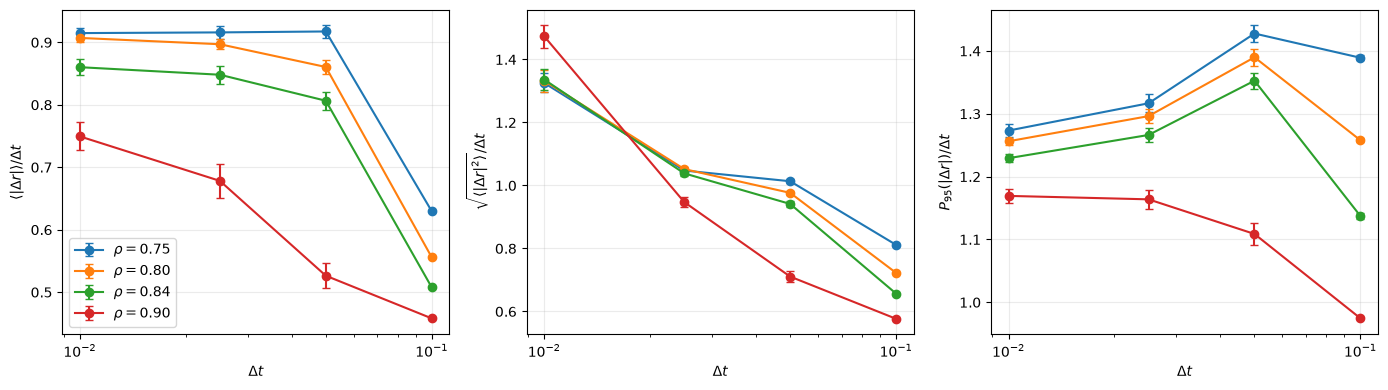

In [15]:
velocity_metrics = {
    "v_mean_step": r"$\langle |\Delta r| \rangle / \Delta t$",
    "v_rms_step": r"$\sqrt{\langle |\Delta r|^2 \rangle} / \Delta t$",
    "v_p95_step": r"$P_{95}(|\Delta r|) / \Delta t$",
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4),
    sharex=True,
)

for ax, (column, label) in zip(
    axes,
    velocity_metrics.items(),
):
    for rho in available_densities:
        subset = (
            velocity_summary[
                velocity_summary["rho"] == rho
            ]
            .sort_values("delta_t")
        )

        x = subset["delta_t"]
        y = subset[(column, "mean")]
        yerr = subset[(column, "sem")]

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            marker="o",
            capsize=3,
            label=fr"$\rho={rho:.2f}$",
        )

    ax.set_xscale("log")
    ax.set_xlabel(r"$\Delta t$")
    ax.set_ylabel(label)
    ax.grid(alpha=0.25)

axes[0].legend()

plt.tight_layout()
plt.show()

## 4. Geometric stability

Large integration timesteps may allow cells to move too far during a single update, generating artificially large overlaps before the repulsive interaction can respond.
We therefore examine the normalized overlap

$$
\xi_{ij}=\frac{I_{ij}}{I_{ij}^0},
$$

focusing on large-overlap events. This diagnostic is particularly relevant for the regularized interaction, whose repulsive strength increases rapidly as \(\xi\rightarrow1\).
Rather than using the absolute maximum over an entire simulation, which may be dominated by a single event, we characterize each realization using the 95th percentile of the interval maximum overlap during the stationary window.

In [16]:
overlap_steady = overlap[
    (overlap["time_end"] >= T_STEADY_MIN)
    & (overlap["time_end"] <= T_FINAL)
].copy()

overlap_per_seed = (
    overlap_steady
    .groupby(["rho", "delta_t", "seed"])
    .agg(
        mean_overlap=(
            "mean_normalized_overlap",
            "mean",
        ),
        p95_max_overlap=(
            "max_normalized_overlap",
            lambda x: np.percentile(x, 95),
        ),
    )
    .reset_index()
)

In [17]:
overlap_summary = (
    overlap_per_seed
    .groupby(["rho", "delta_t"])
    [["mean_overlap", "p95_max_overlap"]]
    .agg(["mean", "sem"])
    .reset_index()
)

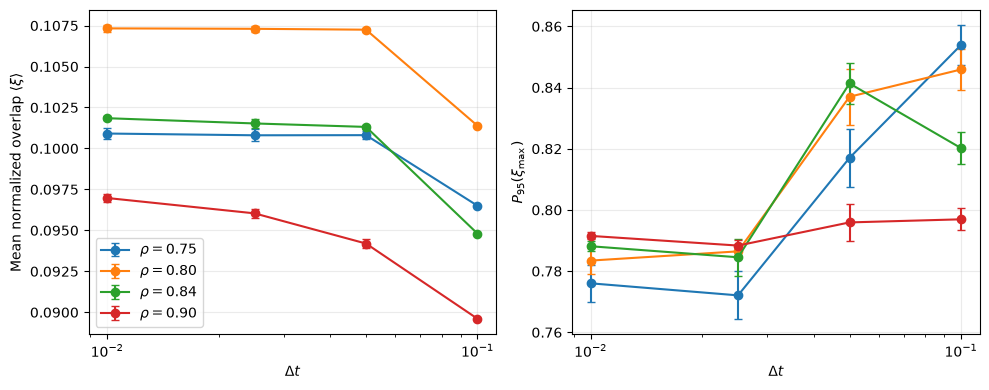

In [18]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    sharex=True,
)

overlap_metrics = {
    "mean_overlap": r"Mean normalized overlap $\langle \xi \rangle$",
    "p95_max_overlap": r"$P_{95}(\xi_{\max})$",
}

for ax, (column, ylabel) in zip(
    axes,
    overlap_metrics.items(),
):
    for rho in available_densities:
        subset = (
            overlap_summary[
                overlap_summary["rho"] == rho
            ]
            .sort_values("delta_t")
        )

        ax.errorbar(
            subset["delta_t"],
            subset[(column, "mean")],
            yerr=subset[(column, "sem")],
            marker="o",
            capsize=3,
            label=fr"$\rho={rho:.2f}$",
        )

    ax.set_xscale("log")
    ax.set_xlabel(r"$\Delta t$")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)

axes[0].legend()

plt.tight_layout()
plt.show()

Large timesteps produce systematically larger extreme overlaps for several densities, indicating that cells can penetrate further into the strongly repulsive part of the interaction before the numerical update resolves the response. The effect is strongly reduced for the smaller timesteps.

## 5. Macroscopic convergence

Numerical differences at the level of individual cell motion and overlap are relevant only if they modify the collective dynamics of the model. We therefore examine the fraction of elongated cells,

$$
f_E = \frac{N_E}{N},
$$

which directly reflects the outcome of the deformation dynamics.

We first compare the temporal evolution of $f_E$ at fixed physical time and then quantify its stationary value for each timestep.

In [19]:
fe_time = (
    order_parameters
    .groupby(["rho", "delta_t", "time"])["fraction_elongated"]
    .agg(["mean", "sem"])
    .reset_index()
)

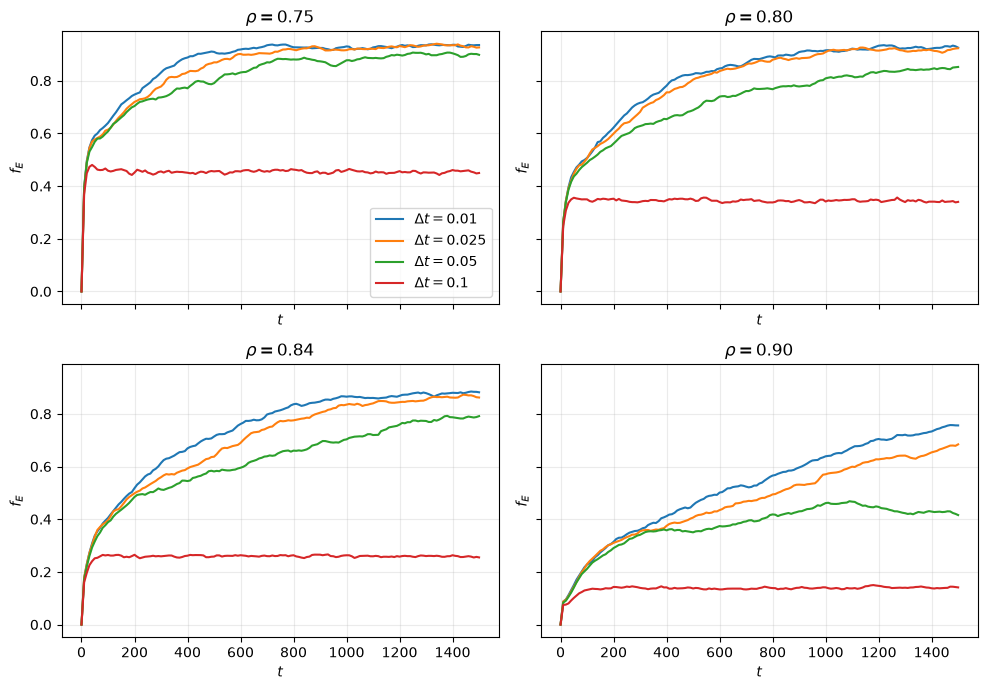

In [20]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 7),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()

for ax, rho in zip(axes, available_densities):
    subset_rho = fe_time[
        fe_time["rho"] == rho
    ]

    for dt in available_delta_ts:
        subset = (
            subset_rho[
                subset_rho["delta_t"] == dt
            ]
            .sort_values("time")
        )

        ax.plot(
            subset["time"],
            subset["mean"],
            label=fr"$\Delta t={dt:g}$",
        )

    ax.set_title(fr"$\rho={rho:.2f}$")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$f_E$")
    ax.grid(alpha=0.25)

axes[0].legend()

plt.tight_layout()
plt.show()

In [21]:
fe_steady = order_parameters[
    (order_parameters["time"] >= T_STEADY_MIN)
    & (order_parameters["time"] <= T_FINAL)
].copy()

fe_per_seed = (
    fe_steady
    .groupby(
        ["rho", "delta_t", "seed"],
        as_index=False,
    )["fraction_elongated"]
    .mean()
)

In [22]:
fe_summary = (
    fe_per_seed
    .groupby(["rho", "delta_t"])["fraction_elongated"]
    .agg(["mean", "sem"])
    .reset_index()
)

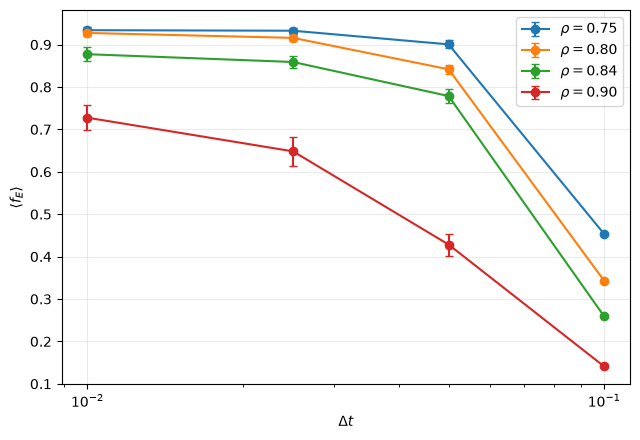

In [23]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

for rho in available_densities:
    subset = (
        fe_summary[
            fe_summary["rho"] == rho
        ]
        .sort_values("delta_t")
    )

    ax.errorbar(
        subset["delta_t"],
        subset["mean"],
        yerr=subset["sem"],
        marker="o",
        capsize=3,
        label=fr"$\rho={rho:.2f}$",
    )

ax.set_xscale("log")
ax.set_xlabel(r"$\Delta t$")
ax.set_ylabel(r"$\langle f_E \rangle$")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

## 6. Structural convergence

As a final macroscopic diagnostic, we examine whether the integration timestep affects the spatial organization of elongated cells.

Spatial clusters are defined using the same normalized-overlap threshold as the interaction network (range_factor = 1). To separate collective organization from the timestep dependence already observed in the elongated-cell fraction, we use the fraction of elongated cells belonging to the largest elongated cluster,

$$
\frac{S_{1,E}}{N_E}.
$$

This quantity measures clustering within the elongated population rather than the absolute number of elongated cells.

In [24]:
(
    clusters[
        ["phenotype", "alignment", "range_factor"]
    ]
    .drop_duplicates()
    .sort_values(
        ["phenotype", "alignment", "range_factor"]
    )
)

,phenotype,alignment,range_factor
0,elongated,nematic,1.0
1,elongated,nematic,1.1
2,elongated,polar,1.0
3,elongated,polar,1.1
4,elongated,spatial,1.0
5,elongated,spatial,1.1
6,round,spatial,1.0
7,round,spatial,1.1


In [25]:
elongated_spatial = clusters[
    (clusters["phenotype"] == "elongated")
    & (clusters["alignment"] == "spatial")
    & np.isclose(clusters["range_factor"], 1.0)
].copy()

In [26]:
cluster_late = elongated_spatial[
    (elongated_spatial["time"] >= T_STEADY_MIN)
    & (elongated_spatial["time"] <= T_FINAL)
].copy()

cluster_per_seed = (
    cluster_late
    .groupby(
        ["rho", "delta_t", "seed"],
        as_index=False,
    )["S1_over_Nphenotype"]
    .mean()
)

In [27]:
cluster_summary = (
    cluster_per_seed
    .groupby(["rho", "delta_t"])["S1_over_Nphenotype"]
    .agg(["mean", "sem"])
    .reset_index()
)

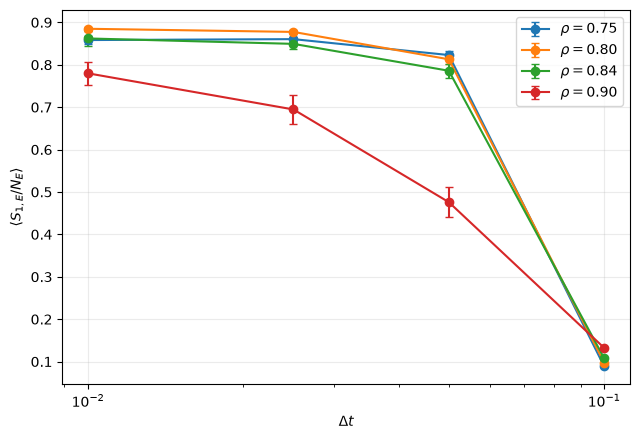

In [28]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

for rho in available_densities:
    subset = (
        cluster_summary[
            cluster_summary["rho"] == rho
        ]
        .sort_values("delta_t")
    )

    ax.errorbar(
        subset["delta_t"],
        subset["mean"],
        yerr=subset["sem"],
        marker="o",
        capsize=3,
        label=fr"$\rho={rho:.2f}$",
    )

ax.set_xscale("log")
ax.set_xlabel(r"$\Delta t$")
ax.set_ylabel(r"$\langle S_{1,E}/N_E\rangle$")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

In [29]:
cluster_comparison = (
    cluster_late
    .groupby(
        ["rho", "delta_t", "seed"],
        as_index=False,
    )[["S1_over_N", "S1_over_Nphenotype"]]
    .mean()
)

## 7. Orientational convergence

As a final collective diagnostic, we examine orientational order within the elongated-cell population. Since the polar and nematic order parameters are normalized by the number of elongated cells, they provide information complementary to the elongated-cell fraction.
We compare

$$
P =
\frac{1}{N_E}
\left|
\sum_{i\in E}\mathbf e_i
\right|,
$$

and the corresponding nematic order parameter $Q$.

In [30]:
op_late = order_parameters[
    (order_parameters["time"] >= T_STEADY_MIN)
    & (order_parameters["time"] <= T_FINAL)
].copy()

op_per_seed = (
    op_late
    .groupby(
        ["rho", "delta_t", "seed"],
        as_index=False,
    )[["polar", "nematic"]]
    .mean()
)

In [31]:
op_summary = (
    op_per_seed
    .groupby(["rho", "delta_t"])
    [["polar", "nematic"]]
    .agg(["mean", "sem"])
    .reset_index()
)

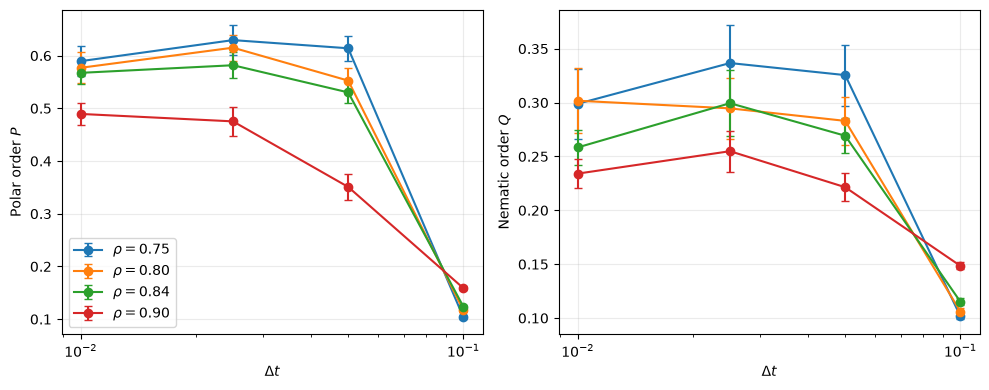

In [32]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    sharex=True,
)

op_metrics = {
    "polar": r"Polar order $P$",
    "nematic": r"Nematic order $Q$",
}

for ax, (column, ylabel) in zip(
    axes,
    op_metrics.items(),
):
    for rho in available_densities:
        subset = (
            op_summary[
                op_summary["rho"] == rho
            ]
            .sort_values("delta_t")
        )

        ax.errorbar(
            subset["delta_t"],
            subset[(column, "mean")],
            yerr=subset[(column, "sem")],
            marker="o",
            capsize=3,
            label=fr"$\rho={rho:.2f}$",
        )

    ax.set_xscale("log")
    ax.set_xlabel(r"$\Delta t$")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)

axes[0].legend()

plt.tight_layout()
plt.show()